
Tokens:
['a', 'inteligencia', 'artificial', 'aprende', 'padroes']

IDs:
tensor([0, 1, 2, 3, 4])

Embeddings:
torch.Size([5, 8])

Q shape: torch.Size([5, 8])
K shape: torch.Size([5, 8])
V shape: torch.Size([5, 8])

Scores:
tensor([[ 0.2417,  0.0410,  0.4208, -0.1744,  0.2345],
        [ 0.2049,  0.2677,  0.4230, -0.4276,  0.1238],
        [ 0.3959, -0.1193,  0.0531, -0.4805,  0.0994],
        [-0.0085, -0.0359, -0.1660,  0.7436,  0.1149],
        [ 0.3824,  0.2717,  0.3282, -0.0235,  0.3181]], grad_fn=<DivBackward0>)

Attention Weights:
tensor([[0.2143, 0.1753, 0.2563, 0.1413, 0.2127],
        [0.2100, 0.2236, 0.2612, 0.1116, 0.1936],
        [0.2884, 0.1723, 0.2047, 0.1201, 0.2144],
        [0.1645, 0.1600, 0.1405, 0.3489, 0.1861],
        [0.2249, 0.2013, 0.2130, 0.1499, 0.2109]], grad_fn=<SoftmaxBackward0>)

Saída:
tensor([[-0.3282,  0.3328, -0.4384,  0.3015, -0.1479, -0.0216,  0.1284, -0.4633],
        [-0.3025,  0.4000, -0.4818,  0.2655, -0.1569, -0.0455,  0.1444, -0.4701],
      

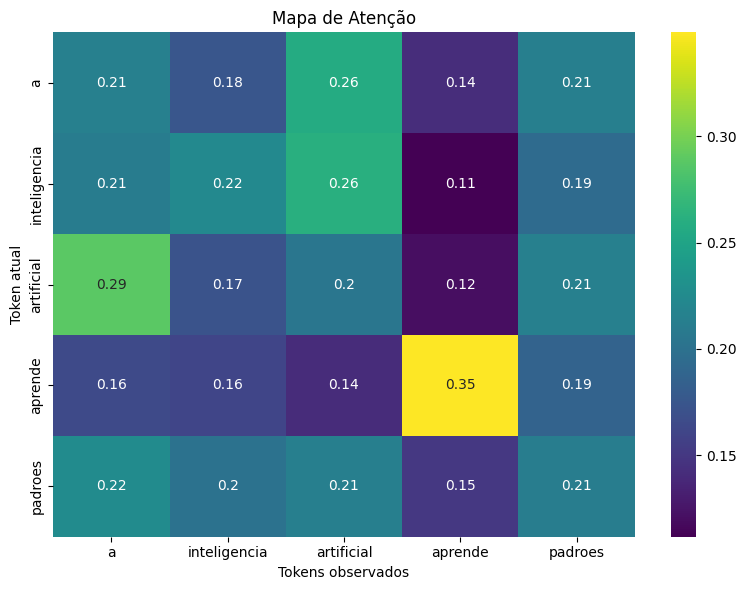

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# FRASE DE EXEMPLO
# ============================================================

sentence = "a inteligencia artificial aprende padroes"

tokens = sentence.split()

print("\nTokens:")
print(tokens)

# ============================================================
# VOCABULÁRIO
# ============================================================

vocab = {word: idx for idx, word in enumerate(tokens)}

token_ids = torch.tensor([vocab[t] for t in tokens])

print("\nIDs:")
print(token_ids)

# ============================================================
# EMBEDDINGS
# ============================================================

embedding_dim = 8

embedding = nn.Embedding(len(vocab), embedding_dim)

x = embedding(token_ids)

print("\nEmbeddings:")
print(x.shape)

# ============================================================
# SELF ATTENTION
# ============================================================

class SelfAttention(nn.Module):

    def __init__(self, embed_dim):

        super().__init__()

        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):

        # ----------------------------------------------------
        # Gera Q, K e V
        # ----------------------------------------------------

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        print("\nQ shape:", Q.shape)
        print("K shape:", K.shape)
        print("V shape:", V.shape)

        # ----------------------------------------------------
        # Attention Scores
        # ----------------------------------------------------

        dk = K.shape[-1]

        scores = torch.matmul(Q, K.T) / np.sqrt(dk)

        print("\nScores:")
        print(scores)

        # ----------------------------------------------------
        # Softmax
        # ----------------------------------------------------

        attention_weights = torch.softmax(scores, dim=-1)

        print("\nAttention Weights:")
        print(attention_weights)

        # ----------------------------------------------------
        # Saída Final
        # ----------------------------------------------------

        output = torch.matmul(attention_weights, V)

        return output, attention_weights


attention = SelfAttention(embedding_dim)

output, weights = attention(x)

print("\nSaída:")
print(output)

# ============================================================
# VISUALIZAÇÃO
# ============================================================

weights_np = weights.detach().numpy()

plt.figure(figsize=(8,6))

sns.heatmap(
    weights_np,
    annot=True,
    cmap="viridis",
    xticklabels=tokens,
    yticklabels=tokens
)

plt.title("Mapa de Atenção")
plt.xlabel("Tokens observados")
plt.ylabel("Token atual")

plt.tight_layout()
plt.show()